## 00. Import Required Packages and Tools

In [1]:
# Quick verification of wave_tools availability
import os
import sys
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from pathlib import Path
WAVE_TOOLS_PATH = Path("/work/mh1498/m301257/wave_tools")
sys.path.insert(0, str(WAVE_TOOLS_PATH.parent))
import pandas as pd
from wave_tools import (save_figure)
from wave_tools.spectral import (WKSpectralAnalysis, SpectralConfig)
from wave_tools.plotting import (set_axis_for_wave)
# 图像保存路径
fig_save_path = "/work/mh1498/m301257/figures/wave_different_resolution/"
os.makedirs(fig_save_path, exist_ok=True)

# 地球物理常数
EARTH_RADIUS = 6.37e6  # 地球半径 (m)

# Check key files
key_files = ['__init__.py', 'spectral.py', 'plotting.py', 'utils.py']
print(f"\n2. Key files check:")
for file in key_files:
    file_path = os.path.join(WAVE_TOOLS_PATH, file)
    exists = os.path.exists(file_path)
    symbol = "✓" if exists else "✗"
    print(f"   {symbol} {file}: {'exists' if exists else 'not found'}")




2. Key files check:
   ✓ __init__.py: exists
   ✓ spectral.py: exists
   ✓ plotting.py: exists
   ✓ utils.py: exists


## 02. Kelvin Wave Selection and Phase Speed Calculation Core Functions

Implementation based on the methodology from Cal_+4K_data_kelvin.ipynb

In [2]:
def create_kelvin_wave_mask(
    frequency: np.ndarray,
    wavenumber: np.ndarray,
    fmin: float = 1/20,
    fmax: float = 1/3,
    kmin: int = 2,
    kmax: int = 14,
    hmin: float = 8,
    hmax: float = 90
):
    
    """
    创建Kelvin波的频率-波数空间掩码
    
    参考: Wheeler & Kiladis (1999) 的Kelvin波选择标准
    频率范围: 0.03-0.3 cpd
    波数范围: 1-14
    等效深度: 8-90m (对应相速度约8-30 m/s)
    """
    EARTH_CIRCUMFERENCE = 40075e3  # 地球周长 (m)
    
    SECONDS_PER_DAY = 86400  # 每天秒数
    # 地球参数
    a = EARTH_RADIUS  # 地球半径 (m)
    g = 9.81  # 重力加速度 (m/s^2)
    beta = 2.28e-11  # 科氏参数变化率 (1/m/s)
    knum, freq = np.meshgrid(wavenumber, frequency)
    
    mask = np.zeros(knum.shape, dtype=bool)
    
    # 应用频率和波数范围
    mask = mask | (knum < kmin) | (knum > kmax)
    mask = mask | (freq < fmin) | (freq > fmax)
    
    # 应用等效深度范围（Kelvin波色散关系）
    if hmin is not None:
        c = np.sqrt(g * hmin)
        omega = 2. * np.pi * freq / 24. / 3600. / np.sqrt(beta * c)
        k = knum / a * np.sqrt(c / beta)
        mask = mask | (omega - k < 0)
    
    if hmax is not None:
        c = np.sqrt(g * hmax)
        omega = 2. * np.pi * freq / 24. / 3600. / np.sqrt(beta * c)
        k = knum / a * np.sqrt(c / beta)
        mask = mask | (omega - k > 0)
    
    valid_mask = ~mask
    
    return valid_mask.astype(float)


def calculate_kelvin_wave_metrics(analysis, freq_array, wnum_array):
    """
    计算Kelvin波的关键指标：
    1. 标准化频谱总强度
    2. 频谱加权平均相速度
    
    参数:
        analysis: WKSpectralAnalysis对象
        freq_array: 频率数组
        wnum_array: 波数数组
    
    返回:
        dict: 包含power_norm_total和speed_norm_avg的字典
    """
    a = EARTH_RADIUS  # 地球半径 (m)
    # 创建Kelvin波掩码
    valid_mask = create_kelvin_wave_mask(freq_array, wnum_array)
    
    # 获取标准化频谱
    power_sym = analysis.power_symmetric
    background = analysis.background
    
    normlized_spectrum = power_sym / background 
    norm_kelvin = normlized_spectrum * valid_mask
    
    knum, freq = np.meshgrid(wnum_array, freq_array)
    # 转换为numpy数组（如果是xarray）
    # power_sym_np = power_sym.values if hasattr(power_sym, 'values') else power_sym
    # background_np = background.values if hasattr(background, 'values') else background
    
    total_weighted_speed = 0
    total_weight = 0
    
    for i in range(knum.shape[0]):  # 频率维度
        for j in range(knum.shape[1]):  # 波数维度
            if valid_mask[i, j] and norm_kelvin[i, j] > 0:  # 有效且有功率
                f_val = freq[i, j]
                k_val = knum[i, j]
                
                # 计算相速度
                phase_speed = (2 * np.pi * f_val / 86400) / (k_val /a)
                
                # 用功率值作为权重
                weight = norm_kelvin[i, j]
                total_weighted_speed += phase_speed * weight
                total_weight += weight
    
    # 计算加权平均相速度
    if total_weight > 0:
        avg_phase_speed = total_weighted_speed / total_weight
    else:
        avg_phase_speed = np.nan
        print("警告: 没有找到有效的Kelvin波区域数据点")
    
    return {
        'speed_norm_avg': avg_phase_speed,
        'valid_mask': valid_mask,
        'norm_spectrum': norm_kelvin
    }

print("✅ Kelvin wave analysis functions defined successfully")

✅ Kelvin wave analysis functions defined successfully


## 03. Load Preprocessed Precipitation Data

Use already processed precipitation data (converted to lat-lon grid and mm/day units)

In [3]:
# 指定已处理的数据路径
print("="*70)
print("📁 加载已处理的降水数据...")
print("="*70)

# 数据路径 - 请根据实际情况修改
data_base_path = "/work/mh1498/m301257/converted_data/processed/pr_2d_original"

# 可用的实验列表 - 包含CNTL对照实验
experiments = ['CNTL', '4K', '4CO2']

# 检查是否有已加载的数据
data_dict = {}

print("\n正在加载三个实验的数据:")
print("  - CNTL: 对照实验")
print("  - 4K: +4K SST敏感性实验")
print("  - 4CO2: 4×CO2敏感性实验")

# 加载数据
import xarray as xr
try:
    data_dict['CNTL'] = xr.open_dataset(f"{data_base_path}/cntl/pr_original.nc")['pr'].sel(lat=slice(-15,15))*86400
    print("✓ CNTL数据加载成功")
except Exception as e:
    print(f"⚠️ CNTL数据加载失败: {e}")

try:
    data_dict['4K'] = xr.open_dataset(f"{data_base_path}/p4k/pr_original.nc")['pr'].sel(lat=slice(-15,15))*86400
    print("✓ 4K数据加载成功")
except Exception as e:
    print(f"⚠️ 4K数据加载失败: {e}")

try:
    data_dict['4CO2'] = xr.open_dataset(f"{data_base_path}/4co2/pr_original.nc")['pr'].sel(lat=slice(-15,15))*86400
    print("✓ 4CO2数据加载成功")
except Exception as e:
    print(f"⚠️ 4CO2数据加载失败: {e}")

print("\n" + "="*70)
print(f"✅ 成功加载 {len(data_dict)} 个实验的数据")
print("="*70)

# 显示数据信息
for exp_name, data in data_dict.items():
    if data is not None:
        print(data)
        print(f"\n{exp_name}:")
        print(f"  形状: {data.shape}")
        print(f"  时间范围: {data.time.values[0]} 到 {data.time.values[-1]}")

📁 加载已处理的降水数据...

正在加载三个实验的数据:
  - CNTL: 对照实验
  - 4K: +4K SST敏感性实验
  - 4CO2: 4×CO2敏感性实验
✓ CNTL数据加载成功
✓ 4K数据加载成功
✓ 4CO2数据加载成功

✅ 成功加载 3 个实验的数据
<xarray.DataArray 'pr' (time: 5114, lat: 199, lon: 1024)> Size: 4GB
array([[[8.84424895e-02, 2.03539431e-01, 1.63487345e-01, ...,
         2.77281739e-02, 4.81148064e-01, 1.13336742e-01],
        [5.80312684e-02, 1.33040920e-01, 9.43145156e-01, ...,
         2.04726309e-01, 1.32185966e-01, 1.86606310e-02],
        [8.61492008e-03, 8.16179439e-02, 6.74387813e-01, ...,
         1.90616265e-04, 8.84060282e-03, 5.67742973e-04],
        ...,
        [5.17408382e-13, 5.98825189e-13, 6.74753222e-13, ...,
         3.16812006e-13, 4.20183907e-13, 4.30905311e-13],
        [5.02149591e-13, 5.43608127e-13, 6.67873959e-13, ...,
         2.70889268e-13, 3.96838324e-13, 4.22086682e-13],
        [4.09645462e-13, 4.59812852e-13, 5.13493057e-13, ...,
         2.41817064e-13, 2.40152136e-13, 3.82238186e-13]],

       [[8.68029892e-02, 2.60415254e-03, 3.17621743e-03,

## 04. Main Function for Yearly Spectral Analysis

Define function to perform Wheeler-Kiladis spectral analysis for each individual year

In [8]:
def analyze_yearly_spectrum(data, config=None):
    """
    对单个年份的数据进行Wheeler-Kiladis频谱分析
    
    参数:
        data: xr.DataArray, 单年降水数据
        year: int, 年份
        config: SpectralConfig对象，默认为None则使用默认配置
    
    返回:
        dict: 包含频谱分析结果和Kelvin波指标
    """
    year_data = {}
    # 使用默认配置
    if config is None:
        config = SpectralConfig()
    

    print(f"    数据时间范围: {data.time.values[0]} 到 {data.time.values[-1]}")
    print(f"    数据形状: {data.shape}")
    
    # 进行频谱分析
    analysis = WKSpectralAnalysis(config)
    analysis.load_data(data=data)
    analysis.preprocess()
    analysis.compute_spectrum()
    analysis.smooth_background()  # 计算背景谱
    
    # 获取频率和波数数组
    freq_array = analysis.frequency  # 已经是numpy数组
    wnum_array = analysis.wavenumber  # 已经是numpy数组
    
    # 计算Kelvin波指标
    metrics = calculate_kelvin_wave_metrics(analysis, freq_array, wnum_array)
    
    
    print(f"    ✓ 平均相速度: {metrics['speed_norm_avg']:.2f} m/s")
    
    year_data = {    
        'analysis': analysis,
        'metrics': metrics,
        'freq_array': freq_array,
        'wnum_array': wnum_array,
        'time':np.unique(data['time.year'].values)
    }
    return year_data



In [9]:
wk_results = {}
for exp_name, data in data_dict.items():
    if data is None:
        continue
    
    print(f"\n开始分析实验: {exp_name}")
    
    wk_results[exp_name] = analyze_yearly_spectrum(data)
    



开始分析实验: CNTL
    数据时间范围: 1980-01-01T00:00:00.000000000 到 1993-12-31T00:00:00.000000000
    数据形状: (5114, 199, 1024)
数据已加载: (5114, 199, 1024) (time, lat, lon)
预处理中...
预处理完成，耗时 87.9 秒
  数据形状: (5114, 199, 1024)
  纬度范围: [-14.94030313 -14.78593023 -14.63166703 -14.47751219 -14.32346436
 -14.16952221 -14.01568443 -13.86194967 -13.70831664 -13.55478404
 -13.40135055 -13.24801491 -13.09477581 -12.94163199 -12.78858217
 -12.63562509 -12.4827595  -12.32998415 -12.17729779 -12.02469918
 -11.87218709 -11.71976031 -11.56741759 -11.41515774 -11.26297955
 -11.1108818  -10.95886331 -10.80692287 -10.65505932 -10.50327145
 -10.3515581  -10.19991809 -10.04835026  -9.89685344  -9.74542648
  -9.59406823  -9.44277753  -9.29155324  -9.14039422  -8.98929935
  -8.83826747  -8.68729748  -8.53638825  -8.38553865  -8.23474757
  -8.08401391  -7.93333655  -7.78271439  -7.63214632  -7.48163126
  -7.33116811  -7.18075578  -7.03039318  -6.88007923  -6.72981284
  -6.57959294  -6.42941846  -6.27928832  -6.12920146  -5.9

In [11]:
wk_results

{'CNTL': {'analysis': <wave_tools.spectral.WKSpectralAnalysis at 0x7fb71465f800>,
  'metrics': {'speed_norm_avg': <xarray.DataArray ()> Size: 8B
   array(15.48395177)
   Coordinates:
       wavenumber  float64 8B 2.0
       frequency   float64 8B 0.05208,
   'valid_mask': array([[0., 0., 0., ..., 0., 0., 0.],
          [0., 0., 0., ..., 0., 0., 0.],
          [0., 0., 0., ..., 0., 0., 0.],
          ...,
          [0., 0., 0., ..., 0., 0., 0.],
          [0., 0., 0., ..., 0., 0., 0.],
          [0., 0., 0., ..., 0., 0., 0.]], shape=(48, 1023)),
   'norm_spectrum': <xarray.DataArray (frequency: 48, wavenumber: 1023)> Size: 393kB
   array([[nan, nan, nan, ..., nan, nan, nan],
          [ 0.,  0.,  0., ...,  0.,  0.,  0.],
          [ 0.,  0.,  0., ...,  0.,  0.,  0.],
          ...,
          [ 0.,  0.,  0., ...,  0.,  0.,  0.],
          [ 0.,  0.,  0., ...,  0.,  0.,  0.],
          [ 0.,  0.,  0., ...,  0.,  0.,  0.]], shape=(48, 1023))
   Coordinates:
     * frequency   (frequency) f

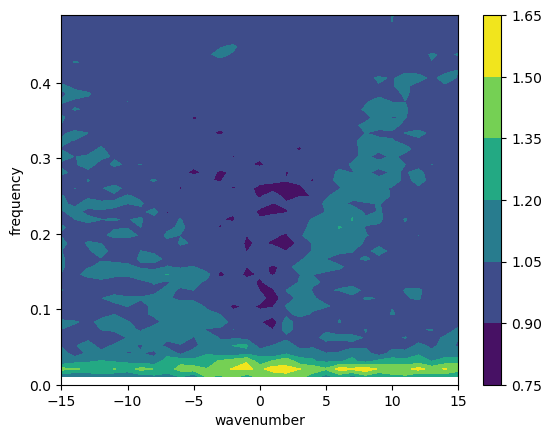

In [29]:
(wk_results['CNTL']['analysis'].power_symmetric/wk_results['CNTL']['analysis'].background).sel(wavenumber=slice(-15,15)).plot.contourf()

In [30]:
import cmaps
cntl_wk = (wk_results['CNTL']['analysis'].power_symmetric/wk_results['CNTL']['analysis'].background).sel(wavenumber=slice(-15,15))
p4k_wk = (wk_results['4K']['analysis'].power_symmetric/wk_results['4K']['analysis'].background).sel(wavenumber=slice(-15,15))
co2_wk = (wk_results['4CO2']['analysis'].power_symmetric/wk_results['4CO2']['analysis'].background).sel(wavenumber=slice(-15,15))

In [63]:
import matplotlib.colors as mcolors
from wave_tools.utils import create_cmap_from_string
color_string = '''

#000000
#800000
#BF1E06
#C91E1E
#D71C2D
#E53935
#F04040
#F56A27
#F9A825
#FCB130
#FDEA9C
#FFFEFD
'''

/home/m/m301257/.conda/envs/xianpu/lib/python3.12/site-packages/matplotlib/text.py:763: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  posy = float(self.convert_yunits(y))
/home/m/m301257/.conda/envs/xianpu/lib/python3.12/site-packages/matplotlib/text.py:568: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  posy = float(self.convert_yunits(self._y))
/home/m/m301257/.conda/envs/xianpu/lib/python3.12/site-packages/matplotlib/text.py:906: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  y = float(self.convert_yunits(self._y))


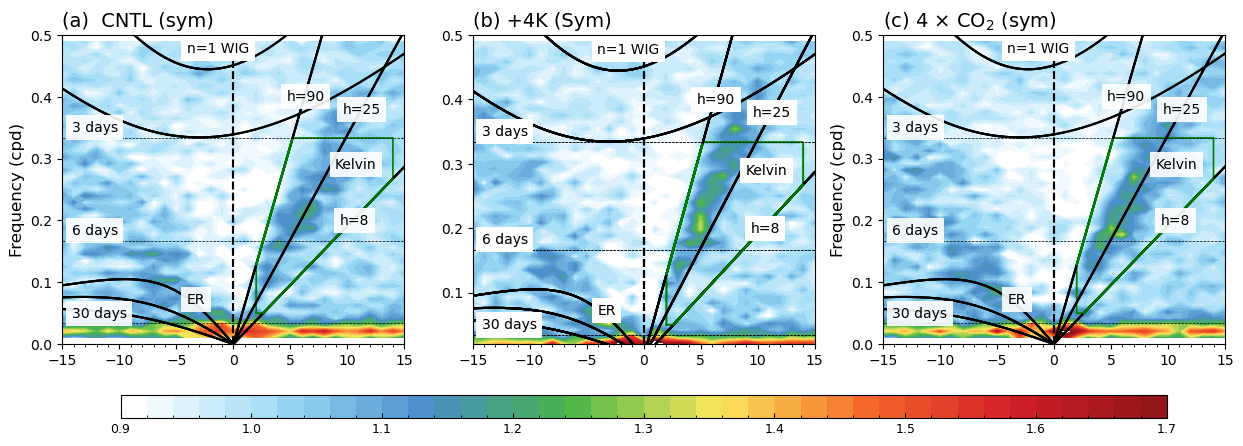

In [99]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5.5))

# 使用发散色图
cmap= cmaps.WhiteBlueGreenYellowRed
# ============ 第1行：CNTL ============

levels_cntl = np.linspace(0.9, 1.7, 41)
im1 = cntl_wk.plot.contourf(
    ax=axes[0], 
    cmap=cmap,
    add_colorbar=False,
    extend='neither', 
    levels=levels_cntl  
)
axes[0].set_title("(a)  CNTL (sym)", fontsize=14, loc='left')

# ============ 第2行：4K  ============
im2 = p4k_wk.plot.contourf(
    ax=axes[1], 
    cmap=cmap,
    add_colorbar=False,
    extend='neither', 
    levels=levels_cntl
)
axes[1].set_title("(b) +4K (Sym)", fontsize=14,  loc='left')

# ============ 第3列：4CO2 - CNTL ============

im3 = co2_wk.plot.contourf(
    ax=axes[2], 
    cmap=cmap,
    add_colorbar=False,
    extend='neither', 
    levels=levels_cntl
)
axes[2].set_title(r"(c) 4 $\times$ CO$_{2}$ (sym)", fontsize=14,  loc='left')

# 格式化所有子图
diff_data = [cntl_wk, p4k_wk, co2_wk]
for i, (ax, data) in enumerate(zip(axes.flat, diff_data)):
    set_axis_for_wave(ax, text_size=16, kelvin_box=True)
    ax.axvline(0, linestyle='--', color='black', linewidth=1.5, alpha=0.7)
    
    ax.set_xlim([-15, 15])
    ax.set_ylim([0, 0.5])
    
    row_idx = i // 2
    if row_idx == 1:
        ax.set_xlabel("", fontsize=12,)
    else:
        ax.set_xlabel("")
    if i % 2 == 0:
        ax.set_ylabel("Frequency (cpd)", fontsize=12)
    else:   
        ax.set_ylabel("", fontsize=12)
        set_axis_for_wave(ax, text_size=16, kelvin_box=True)

cbar = fig.colorbar(im1, ax=axes, orientation='horizontal', shrink=0.9, aspect=45, pad=0.12)
cbar.ax.tick_params(which='both',labelsize=9,direction='in')
# fig.text(0.5, 0.08, "Wavenumber", ha='center', va='center', fontsize=13)

plt.show()
# fig.savefig(f"{fig_save_path}/fig04_power_spectrum_difference_4k_4co2_vs_cntl_mmday.png", dpi=300, bbox_inches='tight')
plt.close(fig)  # 释放内存，避免崩溃